#Proyecto Final
* Jeison Nicolas Diaz Arciniegas
* David Santiago Nagles Barajas
* Miguel Antonio Parradp Pardo

In [11]:
!git clone https://github.com/DavidN110/Final_Project.git


fatal: destination path 'Final_Project' already exists and is not an empty directory.


In [12]:
import pandas as pd

url = "Final_Project/Ceramic_process_QC.xlsx"

data = pd.read_excel(url,sheet_name=None)

list(data.keys())

df_prensas = data['prensas']
df_secadero = data['secadero']
df_horno = data['horno']
df_calidad = data['calidad']

In [13]:
data
#2196 prensas y secadero cada hora
#4390 Horno y calidad cada media hora

for name, df in data.items():
    print(f"--- Hoja: {name} ---")
    print(df.columns)

--- Hoja: prensas ---
Index(['fecha', 'hora_sensor', 'presion_prensa8', 'presion_prensa9'], dtype='object')
--- Hoja: secadero ---
Index(['fecha', 'hora_sensor', 'secadero_temperatura_zona1',
       'secadero_temperatura_zona2', 'secadero_temperatura_zona3',
       'secadero_temperatura_zona4', 'secadero_temperatura_zona5',
       'secadero_temperatura_zona6', 'secadero_temperatura_zona7'],
      dtype='object')
--- Hoja: horno ---
Index(['fecha', 'hora_sensor', 'horno_temperatura_zona8',
       'horno_temperatura_zona10', 'horno_temperatura_zona11',
       'horno_temperatura_zona12', 'horno_temperatura_zona13',
       'horno_temperatura_zona14', 'horno_temperatura_zona15',
       'horno_temperatura_zona16', 'horno_temperatura_zona17',
       'horno_temperatura_zona18', 'horno_temperatura_zona19',
       'horno_temperatura_zona20', 'horno_temperatura_zona21',
       'horno_temperatura_zona22', 'horno_temperatura_zona23',
       'horno_temperatura_zona24', 'horno_temperatura_zona25',
  

In [14]:
cols_to_drop = ["fecha", "hora_sensor"]

dfs = {
    "prensas": df_prensas,
    "secadero": df_secadero,
    "horno": df_horno,
    "calidad": df_calidad
}

dfs_processed = {}

for name, df in dfs.items():
    # Convertir nombres de columnas a minúsculas para comparar
    lower_cols = {c.lower(): c for c in df.columns}

    # columnas que existan en el df original
    to_drop = [ lower_cols[c] for c in cols_to_drop if c in lower_cols ]

    # 1) Drop columnas de tiempo
    df = df.drop(columns=to_drop)

    # 2) Promedio solo en horno y calidad estos valores quiero de 30 min a 1h
    if name in ["horno", "calidad"]:
        # dejar solo columnas numéricas para hacer el promedio
        df = df.select_dtypes(include=['number']).groupby(df.index // 2).mean().reset_index(drop=True)

    dfs_processed[name] = df

dfs_processed["horno"]


,horno_temperatura_zona8,horno_temperatura_zona10,horno_temperatura_zona11,horno_temperatura_zona12,horno_temperatura_zona13,horno_temperatura_zona14,horno_temperatura_zona15,horno_temperatura_zona16,horno_temperatura_zona17,horno_temperatura_zona18,...,horno_temperatura_zona26,horno_temperatura_zona27,horno_temperatura_zona28,horno_temperatura_zona29,horno_temperatura_zona30,horno_temperatura_zona31,horno_temperatura_zona32,horno_temperatura_zona33,horno_temperatura_zona34,horno_temperatura_zona35
0,684.5,692.5,671.5,720.0,737.5,750.0,808.0,836.5,861.5,959.5,...,1169.5,1137.5,1171.0,1139.0,1171.5,1091.5,1140.0,1050.5,1132.0,624.0
1,690.5,690.0,679.0,723.0,736.5,760.0,819.0,842.0,983.0,968.0,...,1172.0,1138.0,1172.0,1135.5,1171.5,1092.0,1140.5,1050.5,1132.5,617.0
2,686.0,689.5,681.0,720.5,738.0,754.5,806.5,838.5,934.5,960.0,...,1172.5,1138.0,1172.0,1135.5,1171.0,1090.5,1140.0,1050.0,1132.0,618.5
3,688.0,687.5,686.0,720.0,738.0,757.0,804.5,838.0,889.0,958.0,...,1172.0,1137.0,1171.5,1135.5,1171.5,1094.5,1141.5,1051.5,1133.0,608.5
4,686.5,693.0,677.0,721.0,735.0,754.5,808.0,840.0,863.5,962.5,...,1172.0,1137.5,1171.5,1137.5,1171.5,1090.5,1140.5,1049.0,1129.5,609.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2190,641.5,629.5,647.0,691.5,681.0,718.0,768.5,799.5,829.5,870.5,...,1161.5,1153.5,1159.5,1153.5,1159.5,1107.5,1201.0,1091.5,1200.0,603.5
2191,643.0,627.5,647.5,690.5,680.5,718.5,769.0,799.0,830.0,871.0,...,1161.0,1153.5,1159.0,1154.0,1159.5,1108.5,1200.0,1095.0,1200.5,608.5
2192,640.5,630.0,648.0,689.5,681.0,718.5,769.5,799.5,830.0,870.0,...,1161.0,1153.5,1160.0,1154.5,1160.0,1109.0,1201.0,1093.0,1200.5,607.0
2193,634.5,634.5,651.0,691.5,683.0,717.5,770.0,799.5,830.0,870.5,...,1164.0,1157.0,1162.5,1156.5,1162.5,1110.5,1200.5,1095.0,1200.0,602.0


In [15]:
import numpy as np

# Unimos prensas, secadero y horno horizontalmente
df_features = pd.concat([
    dfs_processed["prensas"],
    dfs_processed["secadero"],
    dfs_processed["horno"]
], axis=1)

df_labels = dfs_processed["calidad"][["porcentaje_calidad1", "porcentaje_retal"]]

def reducir_labels_por_bloques(df_labels, W):
    reduced = []

    # recorrer en pasos de W
    for i in range(0, len(df_labels), W):
        bloque = df_labels.iloc[i:i+W]

        # evitar bloques incompletos al final
        if len(bloque) == W:
            prom = bloque.mean()
            reduced.append(prom.values)

    # Convertir a DataFrame
    return pd.DataFrame(reduced, columns=df_labels.columns)


def ventanas_por_bloques(df, W):
    X = []

    for i in range(0, len(df), W):
        bloque = df.iloc[i:i+W]

        # evitar bloques incompletos
        if len(bloque) == W:
            X.append(bloque.values)

    return np.array(X)

  ## Si es clase A porcentaje va a ser por encima de
df_labels

,porcentaje_calidad1,porcentaje_retal
0,78.10,1.50
1,78.10,1.50
2,78.10,1.50
3,78.10,1.50
4,78.10,1.50
...,...,...
2190,91.10,0.95
2191,91.55,1.05
2192,90.65,1.05
2193,90.15,1.00


In [16]:
df_labels["calidad1_bin"] = (df_labels["porcentaje_calidad1"] > 50).astype(int)
df_labels["retal_bin"] = (df_labels["porcentaje_retal"] > 50).astype(int)



In [17]:
df_labels = (df_labels > 0).astype(int)

df_labels


,porcentaje_calidad1,porcentaje_retal,calidad1_bin,retal_bin
0,1,1,1,0
1,1,1,1,0
2,1,1,1,0
3,1,1,1,0
4,1,1,1,0
...,...,...,...,...
2190,1,1,1,0
2191,1,1,1,0
2192,1,1,1,0
2193,1,1,1,0


In [18]:
for name, df in dfs_processed.items():
    print("\n===== ", name.upper(), " =====")
    print(df.describe().T[['mean','std','min','max']])
    print("\nValores faltantes:")
    print(df.isna().sum())



=====  PRENSAS  =====
                       mean        std    min    max
presion_prensa8  298.348975  23.933236  239.0  371.0
presion_prensa9  297.771298  22.955202  239.0  359.0

Valores faltantes:
presion_prensa8    0
presion_prensa9    0
dtype: int64

=====  SECADERO  =====
                                  mean        std   min    max
secadero_temperatura_zona1  109.700683  20.439433  32.0  159.0
secadero_temperatura_zona2  184.515718  19.711897  39.0  240.0
secadero_temperatura_zona3  227.741230  26.944328  44.0  265.0
secadero_temperatura_zona4  243.964920  18.542055  45.0  266.0
secadero_temperatura_zona5  244.145786  18.567320  42.0  260.0
secadero_temperatura_zona6  181.331207  24.157360  38.0  229.0
secadero_temperatura_zona7  102.932574  10.339674  31.0  147.0

Valores faltantes:
secadero_temperatura_zona1    0
secadero_temperatura_zona2    0
secadero_temperatura_zona3    0
secadero_temperatura_zona4    0
secadero_temperatura_zona5    0
secadero_temperatura_zona6    0
sec

Hist distribuciones: prensas


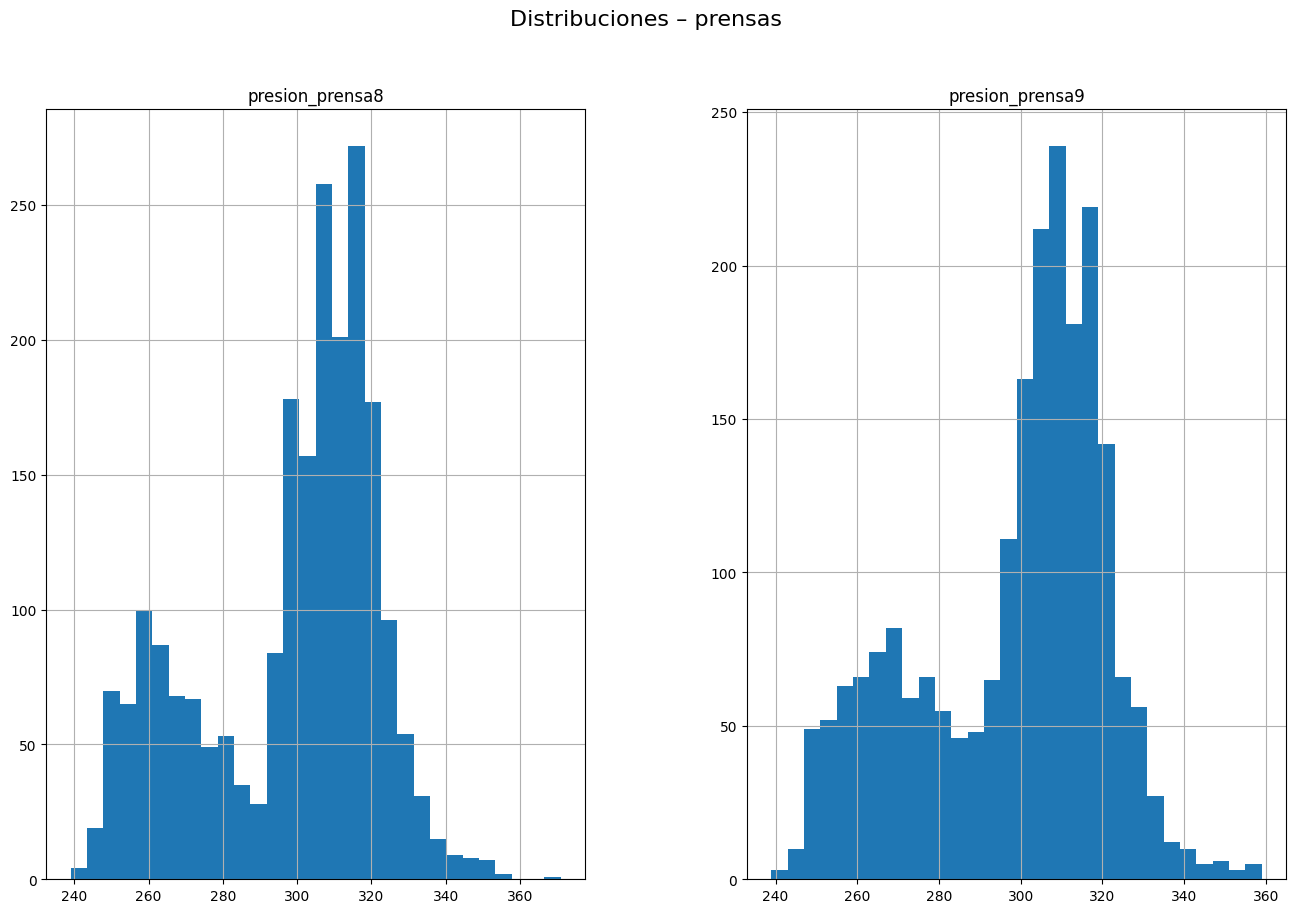

Hist distribuciones: secadero


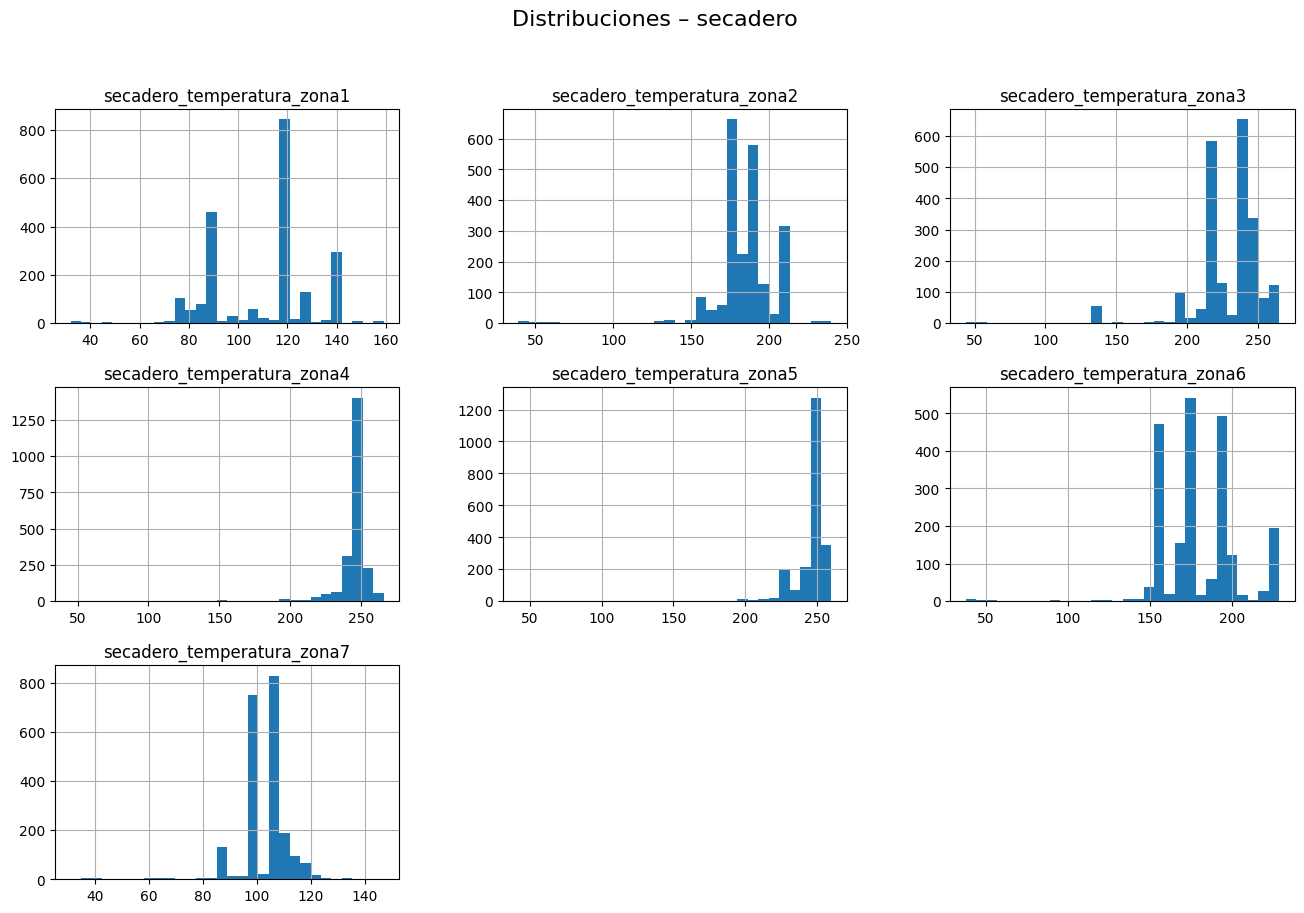

Hist distribuciones: horno


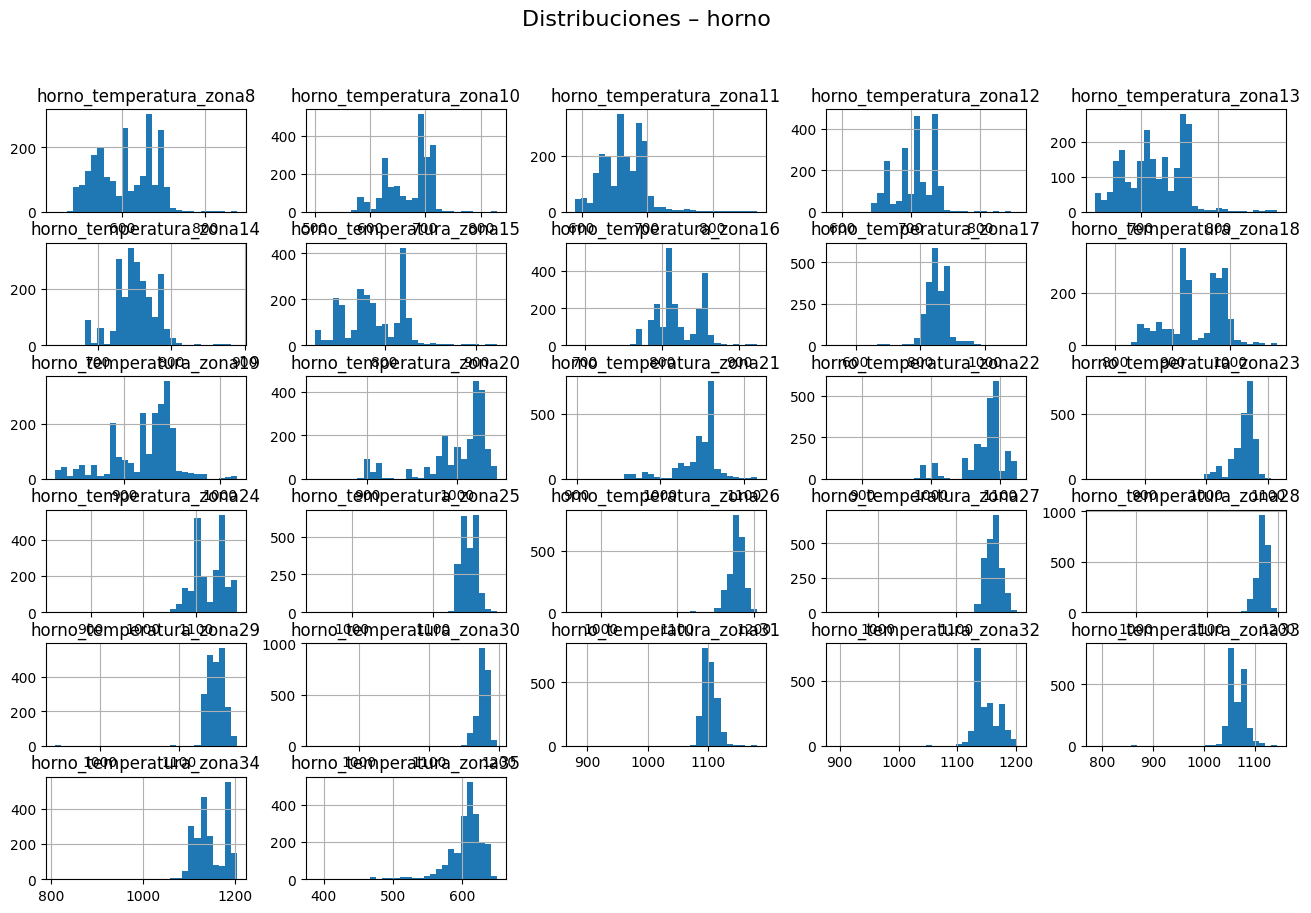

Hist distribuciones: calidad


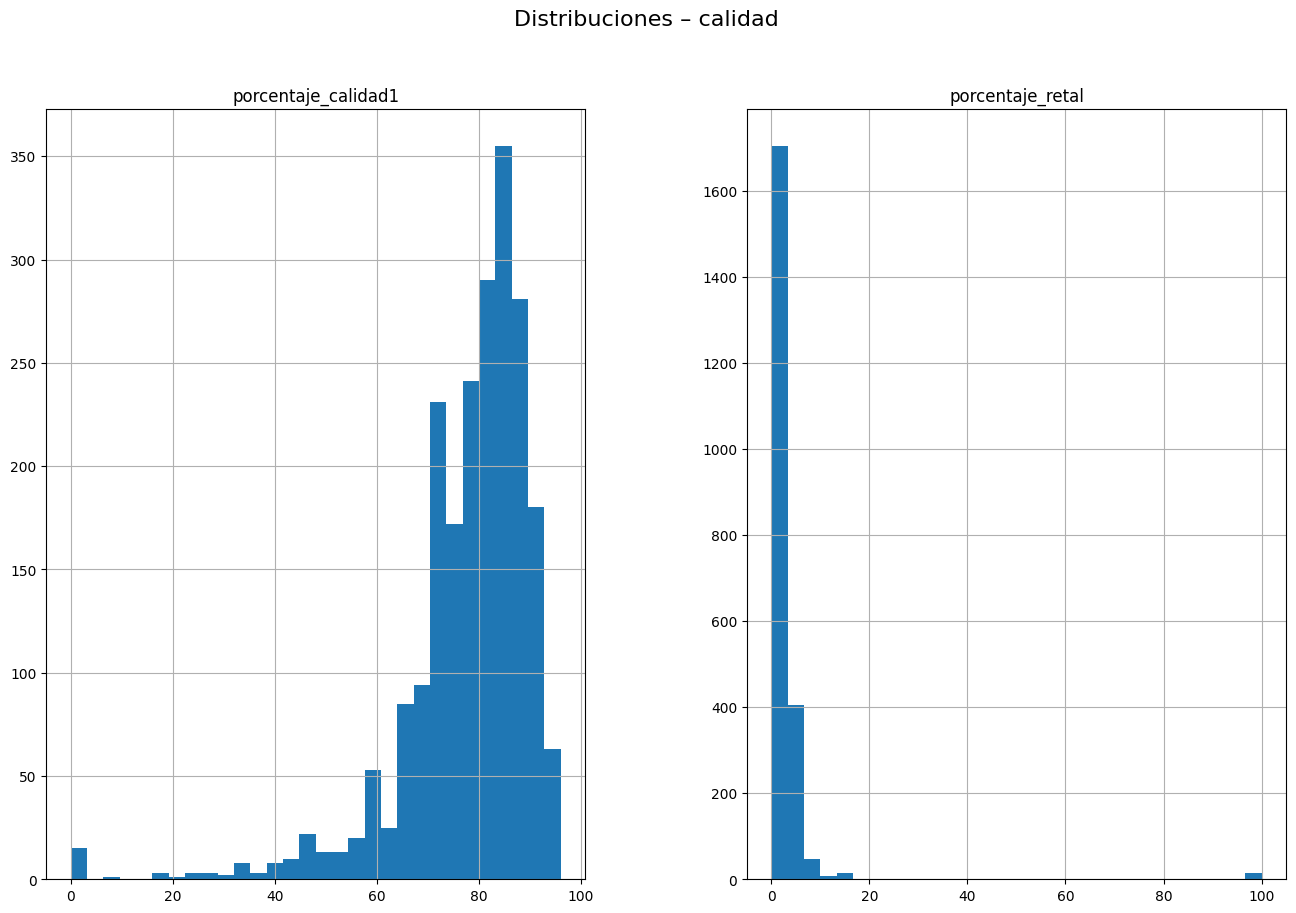

In [19]:
import matplotlib.pyplot as plt

for name, df in dfs_processed.items():
    print("Hist distribuciones:", name)
    df.hist(figsize=(16,10), bins=30)
    plt.suptitle(f"Distribuciones – {name}", fontsize=16)
    plt.show()


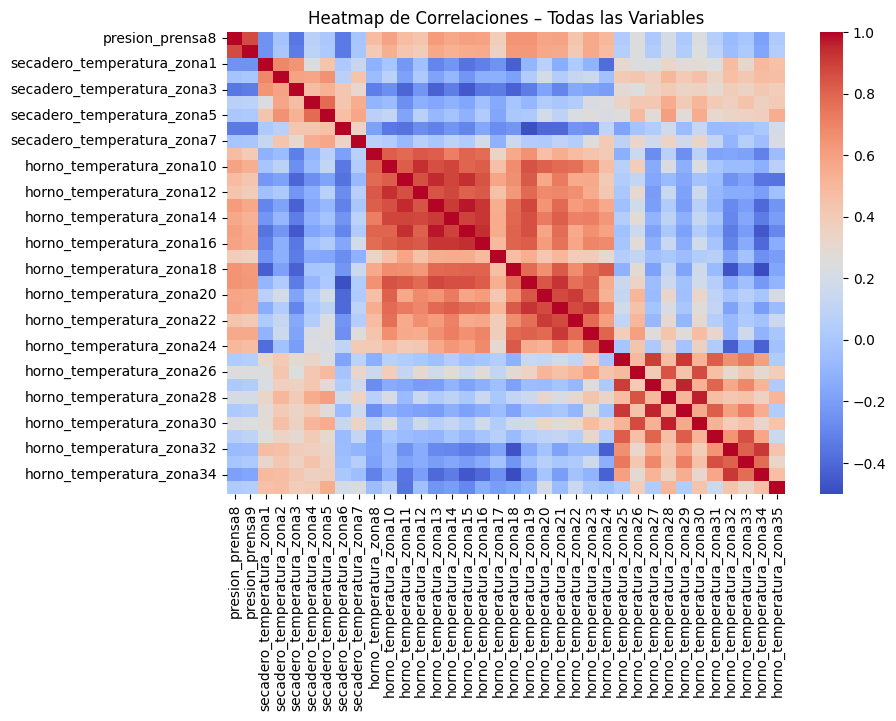

In [20]:
import seaborn as sns
plt.figure(figsize=(9,6))
corr = df_features.corr()
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title("Heatmap de Correlaciones – Todas las Variables")
plt.show()


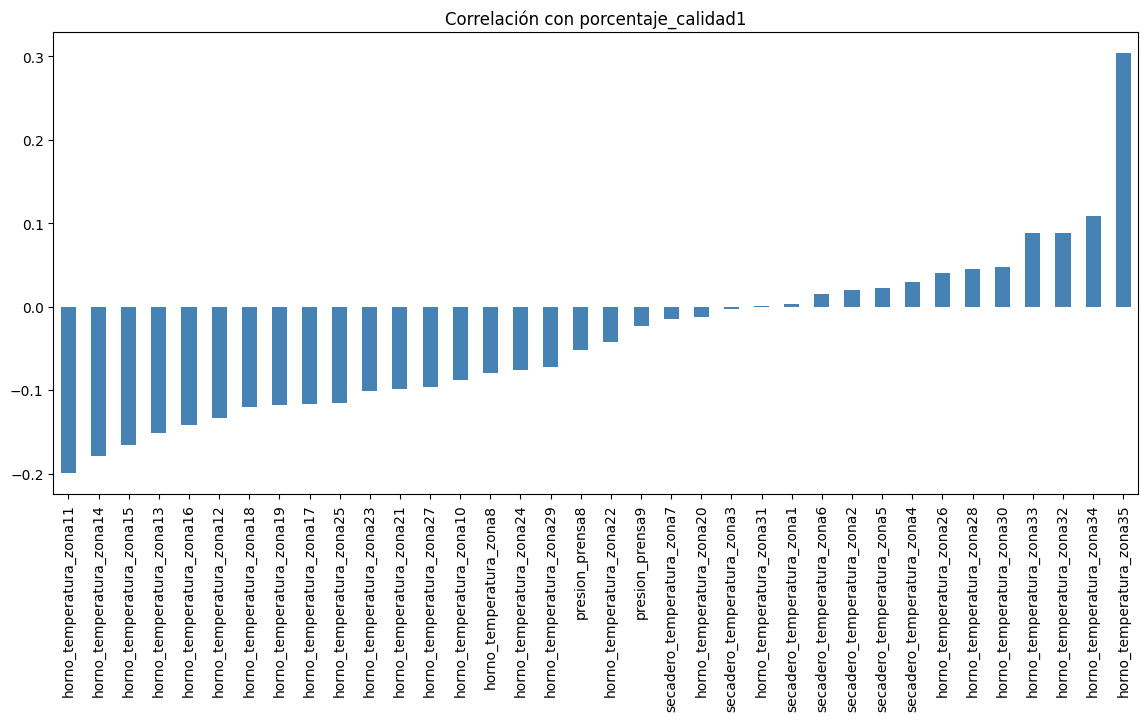

In [21]:
calidad_num = df_labels["porcentaje_calidad1"]

corr_calidad = df_features.corrwith(calidad_num)

plt.figure(figsize=(14,6))
corr_calidad.sort_values().plot(kind="bar", color='steelblue')
plt.title("Correlación con porcentaje_calidad1")
plt.show()


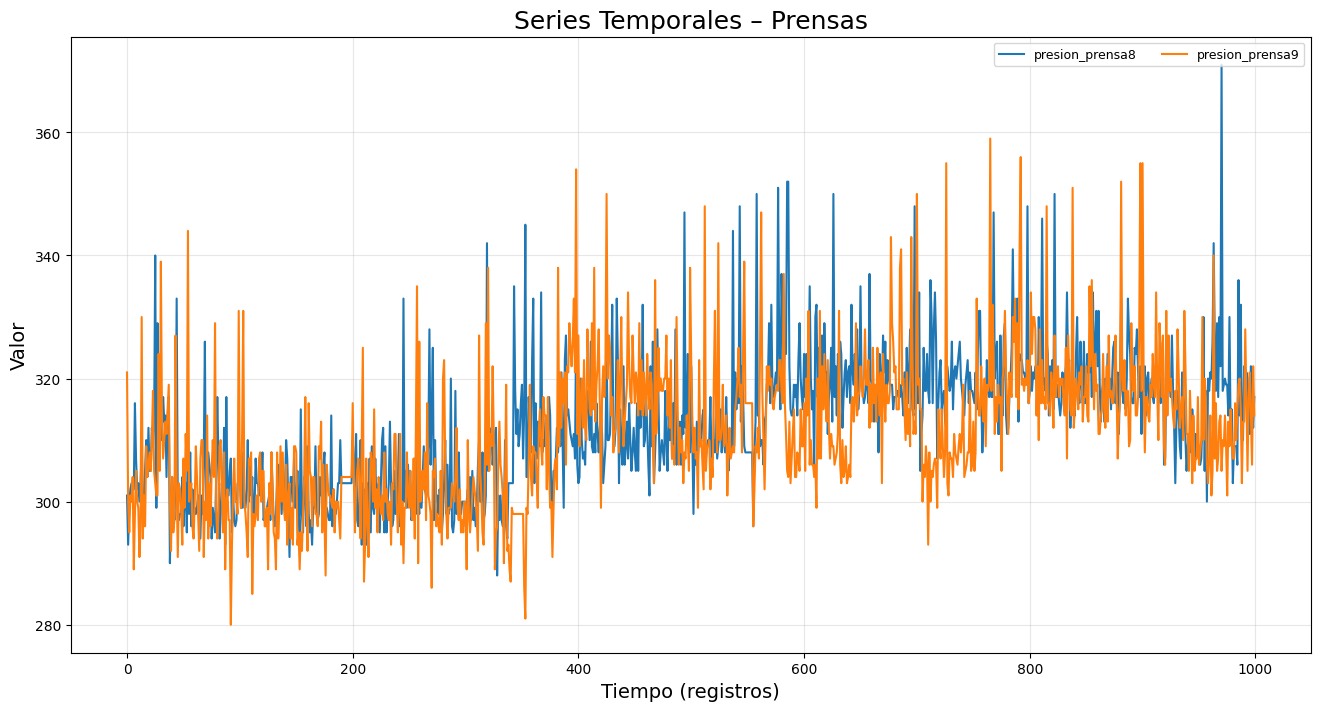

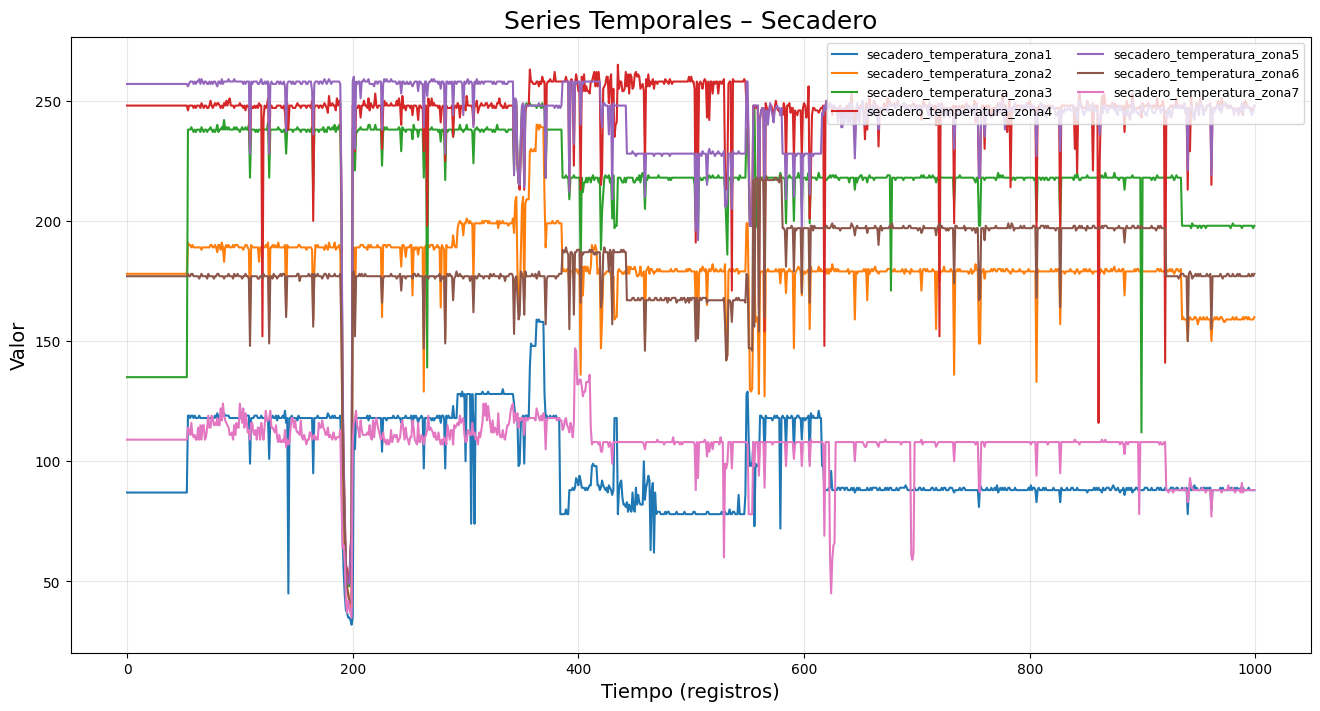

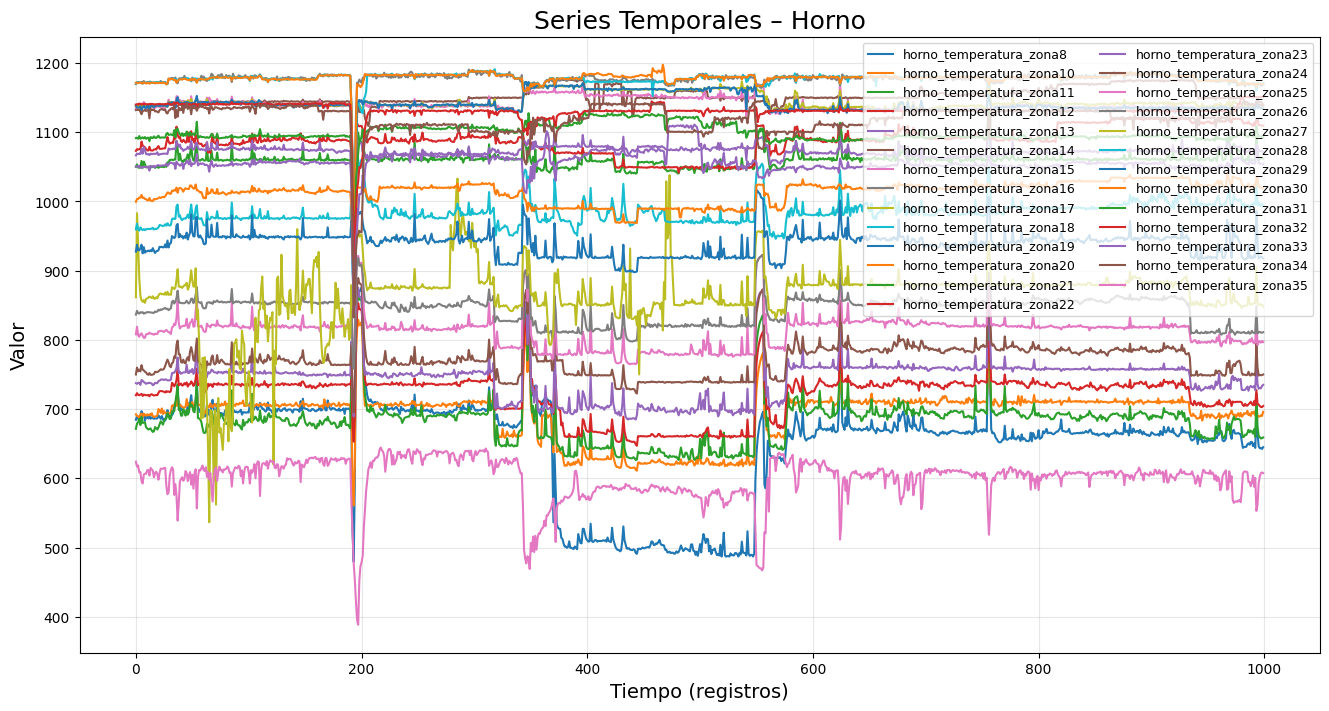

In [22]:
# Número máximo de muestras
N = 1000

# Grupos
groups = {
    "Prensas": dfs_processed["prensas"],
    "Secadero": dfs_processed["secadero"],
    "Horno": dfs_processed["horno"]
}

for group_name, df_group in groups.items():

    plt.figure(figsize=(16, 8))

    for col in df_group.columns:
        plt.plot(df_group[col].iloc[:N], label=col)

    plt.title(f"Series Temporales – {group_name}", fontsize=18)
    plt.xlabel("Tiempo (registros)", fontsize=14)
    plt.ylabel("Valor", fontsize=14)
    plt.legend(loc="upper right", fontsize=9, ncol=2)
    plt.grid(True, alpha=0.3)
    plt.show()


WINDOW DEFINITION

In [23]:
import torch
from torch.utils.data import TensorDataset, DataLoader, random_split

# -------------------------
# 1. Construcción de ventanas
# -------------------------
W = 5

X = ventanas_por_bloques(df_features, W)
y_df = reducir_labels_por_bloques(df_labels, W)
y = y_df["calidad1_bin"].values

# Tensores
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)   #long clasificación

# -------------------------
# 2. Separación en train/test
# -------------------------
dataset = TensorDataset(X_tensor, y_tensor)

train_size = int(0.7 * len(dataset))
test_size  = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# Convertir a tensores independientes para normalizar
X_train = torch.stack([sample[0] for sample in train_dataset])
y_train = torch.stack([sample[1] for sample in train_dataset])

X_test  = torch.stack([sample[0] for sample in test_dataset])
y_test  = torch.stack([sample[1] for sample in test_dataset])

# -------------------------
# 3. Normalización
# -------------------------
mean = X_train.mean(dim=0)
std = X_train.std(dim=0)

# Evitar división por cero
std[std == 0] = 1e-6

X_train_norm = (X_train - mean) / std
X_test_norm  = (X_test - mean) / std

# -------------------------
# 4. Reconstruir datasets
# -------------------------
train_dataset = TensorDataset(X_train_norm, y_train)
test_dataset  = TensorDataset(X_test_norm, y_test)

# -------------------------
# 5. Dataloaders
# -------------------------
batch_size = 32

dataloaderTrain = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
dataloaderTest  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

In [24]:
print("Total dataset:", len(dataset))
print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))
sample, label = dataset[10]
print("Image shape:", sample.shape)
print("Label:", label)

Total dataset: 439
Train size: 307
Test size: 132
Image shape: torch.Size([5, 36])
Label: tensor(1)


CAMBIAR LABEL DE 2 DATOS A SOLO 1 PRIMERO%

In [25]:
X.shape

(439, 5, 36)

In [26]:
y.shape

(439,)

In [27]:
for f,g in dataloaderTrain:
  print(f.shape)
  print(g.shape)

torch.Size([32, 5, 36])
torch.Size([32])
torch.Size([32, 5, 36])
torch.Size([32])
torch.Size([32, 5, 36])
torch.Size([32])
torch.Size([32, 5, 36])
torch.Size([32])
torch.Size([32, 5, 36])
torch.Size([32])
torch.Size([32, 5, 36])
torch.Size([32])
torch.Size([32, 5, 36])
torch.Size([32])
torch.Size([32, 5, 36])
torch.Size([32])
torch.Size([32, 5, 36])
torch.Size([32])
torch.Size([19, 5, 36])
torch.Size([19])


#DNN



In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

class DeepNN(nn.Module):
    def __init__(self, input_size, hidden_size, n_layers, n_out):
        super().__init__()

        layers = []
        layers.append(nn.Linear(input_size, hidden_size))

        for _ in range(n_layers - 1):
            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(nn.ReLU())

        self.hidden_layers = nn.Sequential(*layers)
        self.output_layer = nn.Linear(hidden_size, n_out)

    def forward(self, x):
        y = self.hidden_layers(x)
        z = self.output_layer(y)
        return z


TESTING HYPERPARAMETERS FOR DNN


*** ENTRENAMIENTO DE DNNs CON GRID SEARCH ***

→ Entrenando: Capas=1, Neuronas=20, LR=0.01
→ Entrenando: Capas=1, Neuronas=20, LR=0.001
→ Entrenando: Capas=1, Neuronas=20, LR=0.0001
→ Entrenando: Capas=1, Neuronas=50, LR=0.01
→ Entrenando: Capas=1, Neuronas=50, LR=0.001
→ Entrenando: Capas=1, Neuronas=50, LR=0.0001
→ Entrenando: Capas=1, Neuronas=100, LR=0.01
→ Entrenando: Capas=1, Neuronas=100, LR=0.001
→ Entrenando: Capas=1, Neuronas=100, LR=0.0001
→ Entrenando: Capas=2, Neuronas=20, LR=0.01
→ Entrenando: Capas=2, Neuronas=20, LR=0.001
→ Entrenando: Capas=2, Neuronas=20, LR=0.0001
→ Entrenando: Capas=2, Neuronas=50, LR=0.01
→ Entrenando: Capas=2, Neuronas=50, LR=0.001
→ Entrenando: Capas=2, Neuronas=50, LR=0.0001
→ Entrenando: Capas=2, Neuronas=100, LR=0.01
→ Entrenando: Capas=2, Neuronas=100, LR=0.001
→ Entrenando: Capas=2, Neuronas=100, LR=0.0001
→ Entrenando: Capas=3, Neuronas=20, LR=0.01
→ Entrenando: Capas=3, Neuronas=20, LR=0.001
→ Entrenando: Capas=3, Neuronas=20, LR=0.0001
→

<Figure size 600x600 with 0 Axes>

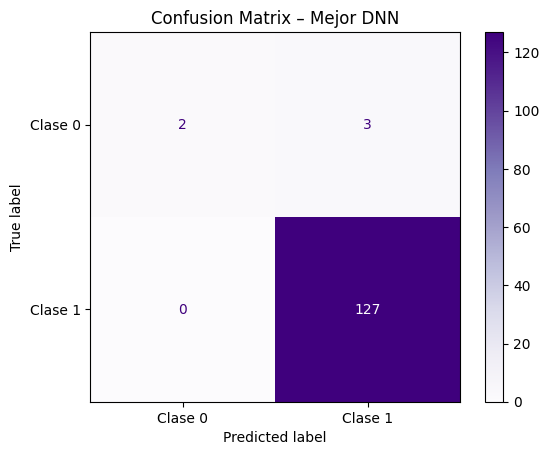

In [118]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ---------------------------------------------------
# 2. FUNCIÓN PARA ENTRENAR Y EVALUAR UNA CONFIGURACIÓN
# ---------------------------------------------------
def train_and_test_DNN(n_layers, hidden_size, lr, n_epochs=20):

    # Obtener input_size del dataloader
    X_sample, _ = next(iter(dataloaderTrain))
    input_size = X_sample.view(X_sample.size(0), -1).shape[1]

    model = DeepNN(input_size, hidden_size, n_layers, n_out=2)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    loss_log = []

    # ----- ENTRENAMIENTO -----
    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0

        for Xb, yb in dataloaderTrain:
            Xb = Xb.view(Xb.size(0), -1).float()
            yb = yb.long()

            logits = model(Xb)
            loss = criterion(logits, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        loss_log.append(epoch_loss / len(dataloaderTrain))

    # ----- EVALUACIÓN -----
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for Xb, yb in dataloaderTest:
            Xb = Xb.view(Xb.size(0), -1).float()
            logits = model(Xb)
            preds = torch.argmax(logits, dim=1)

            y_true.extend(yb.numpy())
            y_pred.extend(preds.numpy())

    accuracy = (np.array(y_true) == np.array(y_pred)).mean()

    return loss_log, accuracy, y_pred, y_true, model

# ---------------------------------------------------
# 3. GRID SEARCH ― DIFERENTES HIPERPARÁMETROS
# ---------------------------------------------------
layer_list   = [1, 2, 3, 4]
neuron_list  = [20, 50, 100]
lr_list      = [0.01, 0.001, 0.0001]

results = {}
accuracies = {}

print("\n*** ENTRENAMIENTO DE DNNs CON GRID SEARCH ***\n")

for L in layer_list:
    for H in neuron_list:
        for LR in lr_list:

            print(f"→ Entrenando: Capas={L}, Neuronas={H}, LR={LR}")

            loss_curve, acc, preds, true, model = train_and_test_DNN(
                n_layers=L,
                hidden_size=H,
                lr=LR,
                n_epochs=20
            )

            key = (L, H, LR)
            results[key] = {
                "loss": loss_curve,
                "acc": acc,
                "preds": preds,
                "true": true,
                "model": model
            }
            accuracies[key] = acc

# ---------------------------------------------------
# 4. MEJOR CONFIGURACIÓN
# ---------------------------------------------------
best_hp = max(accuracies, key=accuracies.get)
best_result = results[best_hp]

print("\n=== MEJOR CONFIGURACIÓN ===")
print(f"Capas ocultas:        {best_hp[0]}")
print(f"Neuronas por capa:    {best_hp[1]}")
print(f"Learning rate:        {best_hp[2]}")
print(f"Accuracy:             {best_result['acc']:.4f}")

# Matriz de confusión de la mejor
cm = confusion_matrix(best_result["true"], best_result["preds"])

plt.figure(figsize=(6,6))
disp = ConfusionMatrixDisplay(cm, display_labels=["Clase 0", "Clase 1"])
disp.plot(cmap="Purples")
plt.title("Confusion Matrix – Mejor DNN")
plt.show()


    layers  neurons      lr  accuracy
0        1       20  0.0100  0.946970
1        1       20  0.0010  0.954545
2        1       20  0.0001  0.848485
3        1       50  0.0100  0.954545
4        1       50  0.0010  0.931818
5        1       50  0.0001  0.893939
6        1      100  0.0100  0.909091
7        1      100  0.0010  0.962121
8        1      100  0.0001  0.840909
9        2       20  0.0100  0.924242
10       2       20  0.0010  0.962121
11       2       20  0.0001  0.969697
12       2       50  0.0100  0.946970
13       2       50  0.0010  0.954545
14       2       50  0.0001  0.962121
15       2      100  0.0100  0.924242
16       2      100  0.0010  0.954545
17       2      100  0.0001  0.969697
18       3       20  0.0100  0.954545
19       3       20  0.0010  0.954545
20       3       20  0.0001  0.946970
21       3       50  0.0100  0.931818
22       3       50  0.0010  0.946970
23       3       50  0.0001  0.962121
24       3      100  0.0100  0.924242
25       3  

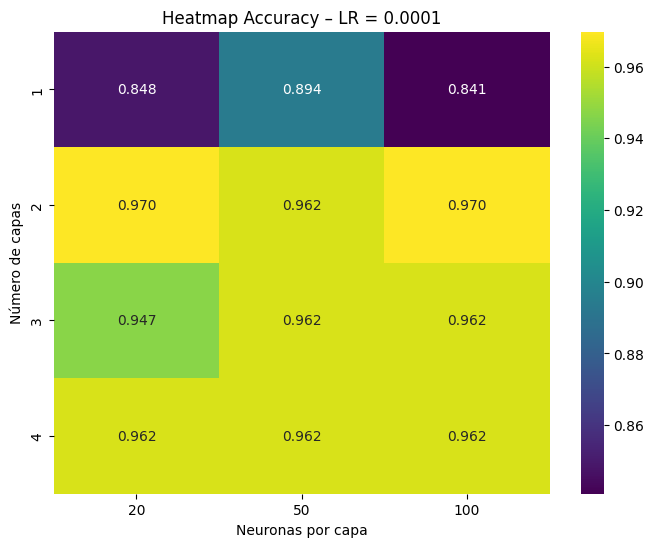

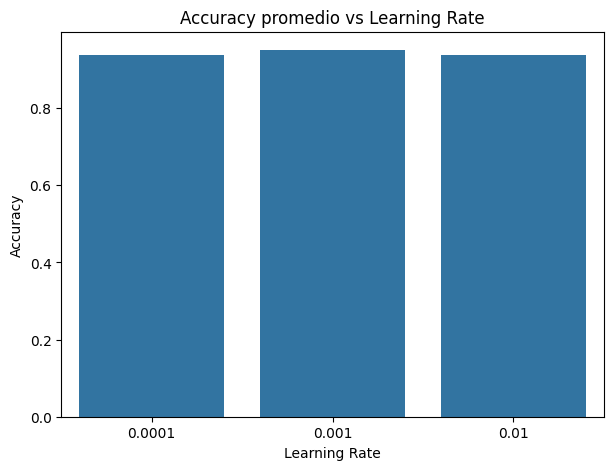

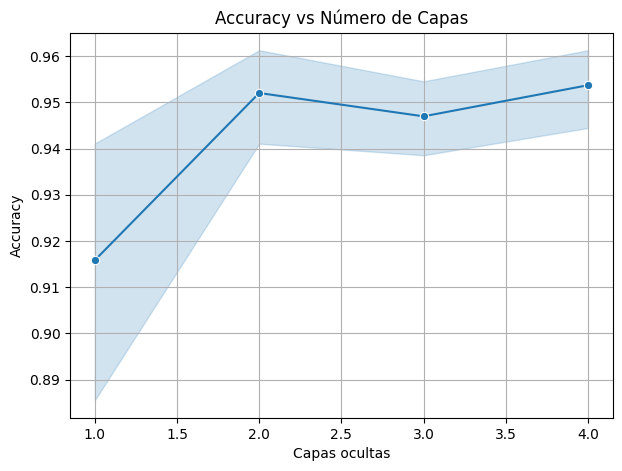

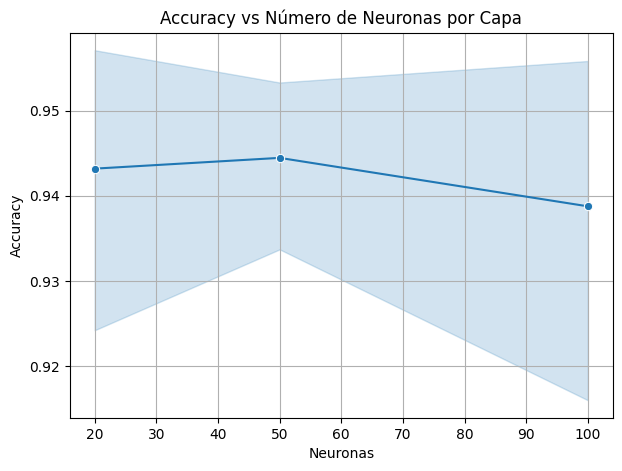

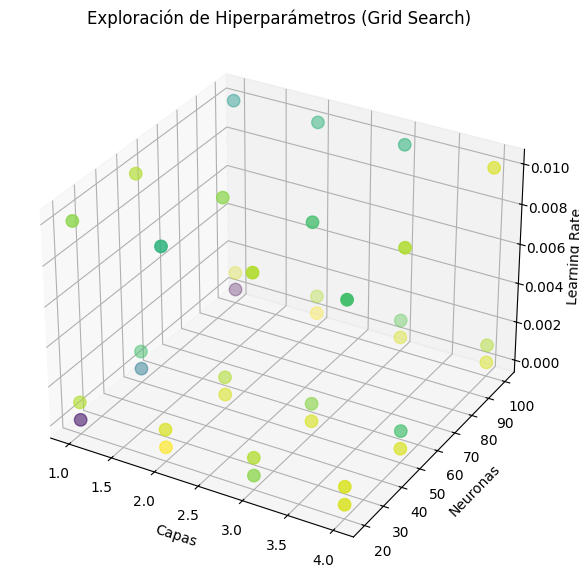

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# Convertimos los resultados a un DataFrame para mejor análisis
# ============================================================
rows = []
for (layers, neurons, lr), acc in accuracies.items():
    rows.append({
        "layers": layers,
        "neurons": neurons,
        "lr": lr,
        "accuracy": acc
    })

df_hp = pd.DataFrame(rows)
print(df_hp)

lr_fixed = 0.0001
df_lr = df_hp[df_hp["lr"] == lr_fixed]

pivot = df_lr.pivot(index="layers", columns="neurons", values="accuracy")

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, cmap="viridis", fmt=".3f")
plt.title(f"Heatmap Accuracy – LR = {lr_fixed}")
plt.xlabel("Neuronas por capa")
plt.ylabel("Número de capas")
plt.show()

plt.figure(figsize=(7,5))
sns.barplot(data=df_hp, x="lr", y="accuracy", errorbar=None)
plt.title("Accuracy promedio vs Learning Rate")
plt.ylabel("Accuracy")
plt.xlabel("Learning Rate")
plt.show()

plt.figure(figsize=(7,5))
sns.lineplot(data=df_hp, x="layers", y="accuracy", marker="o")
plt.title("Accuracy vs Número de Capas")
plt.ylabel("Accuracy")
plt.xlabel("Capas ocultas")
plt.grid(True)
plt.show()

plt.figure(figsize=(7,5))
sns.lineplot(data=df_hp, x="neurons", y="accuracy", marker="o")
plt.title("Accuracy vs Número de Neuronas por Capa")
plt.ylabel("Accuracy")
plt.xlabel("Neuronas")
plt.grid(True)
plt.show()

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df_hp["layers"], df_hp["neurons"], df_hp["lr"],
           c=df_hp["accuracy"], cmap="viridis", s=80)

ax.set_xlabel("Capas")
ax.set_ylabel("Neuronas")
ax.set_zlabel("Learning Rate")
ax.set_title("Exploración de Hiperparámetros (Grid Search)")

plt.show()


Epoch 1, Loss = 0.7866
Epoch 2, Loss = 0.7719
Epoch 3, Loss = 0.7626
Epoch 4, Loss = 0.7532
Epoch 5, Loss = 0.7478
Epoch 6, Loss = 0.7431
Epoch 7, Loss = 0.7348
Epoch 8, Loss = 0.7357
Epoch 9, Loss = 0.7272
Epoch 10, Loss = 0.7215
Epoch 11, Loss = 0.7171
Epoch 12, Loss = 0.7134
Epoch 13, Loss = 0.7093
Epoch 14, Loss = 0.7045
Epoch 15, Loss = 0.7007
Epoch 16, Loss = 0.6972
Epoch 17, Loss = 0.6966
Epoch 18, Loss = 0.6894
Epoch 19, Loss = 0.6844
Epoch 20, Loss = 0.6814


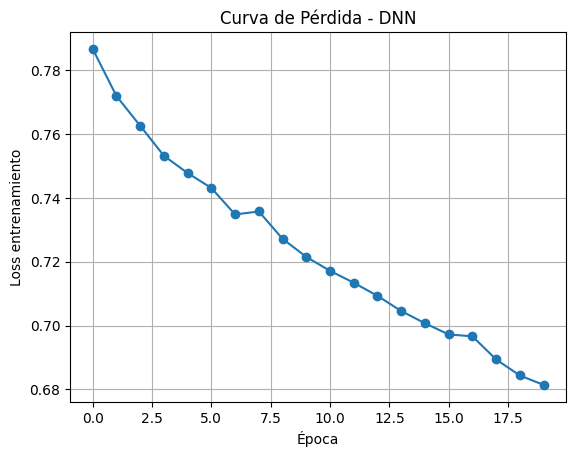


RESULTADOS DEL MODELO
Accuracy en Test: 0.5985
Precision: 0.9744
Recall:    0.5984
F1-score:  0.7415

Matriz de Confusión:
tensor([[ 3,  2],
        [51, 76]], dtype=torch.int32)


In [31]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============
# Preparación
# ============

# Obtener tamaño real de entrada desde un batch
X_sample, _ = next(iter(dataloaderTrain))
input_size = X_sample.view(X_sample.size(0), -1).shape[1]

hidden_size = 20
n_layers = 1
n_out = 2

model = DeepNN(input_size, hidden_size, n_layers, n_out)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

n_epochs = 20
loss_history = []

# ============
# ENTRENAMIENTO
# ============

for epoch in range(1, n_epochs + 1):
    model.train()
    loss_train = 0.0

    for Xb, yb in dataloaderTrain:
        Xb = Xb.float().view(Xb.size(0), -1)
        yb = yb.long().view(-1)

        outputs = model(Xb)
        loss = criterion(outputs, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_train += loss.item()

    epoch_loss = loss_train / len(dataloaderTrain)
    loss_history.append(epoch_loss)

    print(f"Epoch {epoch}, Loss = {epoch_loss:.4f}")

# ============================
# Curva de pérdida opcional
# ============================

plt.plot(loss_history, marker='o')
plt.title("Curva de Pérdida - DNN")
plt.xlabel("Época")
plt.ylabel("Loss entrenamiento")
plt.grid(True)
plt.show()

# ============================
# EVALUACIÓN EN TEST SET
# ============================

model.eval()
correct = 0
total = 0

all_true = []
all_pred = []

with torch.no_grad():
    for Xb, yb in dataloaderTest:
        Xb = Xb.float().view(Xb.size(0), -1)
        yb = yb.long().view(-1)

        outputs = model(Xb)
        preds = torch.argmax(outputs, dim=1)

        correct += (preds == yb).sum().item()
        total += yb.size(0)

        all_true.extend(yb.cpu().numpy())
        all_pred.extend(preds.cpu().numpy())

accuracy = correct / total
print("\n=======================")
print("RESULTADOS DEL MODELO")
print("=======================")
print(f"Accuracy en Test: {accuracy:.4f}")

# ============================
# Métricas solo PyTorch
# ============================

def precision_recall_f1_torch(y_true, y_pred, positive_class=1):
    tp = sum((yt == positive_class) and (yp == positive_class) for yt, yp in zip(y_true, y_pred))
    fp = sum((yt != positive_class) and (yp == positive_class) for yt, yp in zip(y_true, y_pred))
    fn = sum((yt == positive_class) and (yp != positive_class) for yt, yp in zip(y_true, y_pred))

    precision = tp / (tp + fp + 1e-8)
    recall    = tp / (tp + fn + 1e-8)
    f1        = 2 * precision * recall / (precision + recall + 1e-8)

    return precision, recall, f1

precision, recall, f1 = precision_recall_f1_torch(all_true, all_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

# ============================
# Matriz de confusión PyTorch
# ============================

cm = torch.zeros(2, 2, dtype=torch.int32)

for t, p in zip(all_true, all_pred):
    cm[t, p] += 1

print("\nMatriz de Confusión:")
print(cm)


#CNN

In [32]:
for q, qg in dataloaderTrain:
  print(q.shape)
  print(qg.shape)

torch.Size([32, 5, 36])
torch.Size([32])
torch.Size([32, 5, 36])
torch.Size([32])
torch.Size([32, 5, 36])
torch.Size([32])
torch.Size([32, 5, 36])
torch.Size([32])
torch.Size([32, 5, 36])
torch.Size([32])
torch.Size([32, 5, 36])
torch.Size([32])
torch.Size([32, 5, 36])
torch.Size([32])
torch.Size([32, 5, 36])
torch.Size([32])
torch.Size([32, 5, 36])
torch.Size([32])
torch.Size([19, 5, 36])
torch.Size([19])


In [53]:
class CNN(nn.Module):
    def __init__(self, n_k1=16, n_k2=32, k_size=3, pooling="max", fc_neurons=64, n_fc_layers=1, n_out=2):
        super().__init__()
        self.conv1 = nn.Conv2d(1, n_k1, kernel_size=k_size, padding=k_size//2)
        self.bn1 = nn.BatchNorm2d(n_k1)
        self.conv2 = nn.Conv2d(n_k1, n_k2, kernel_size=k_size, padding=k_size//2)
        self.bn2 = nn.BatchNorm2d(n_k2)
        self.pool = nn.MaxPool2d(2) if pooling=="max" else nn.AvgPool2d(2)

        # calcular flatten con dummy según W actual
        dummy = torch.zeros(1,1,5,36)
        x = self.pool(F.relu(self.bn1(self.conv1(dummy))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        flat_dim = x.numel()

        layers = [nn.Linear(flat_dim, fc_neurons), nn.ReLU(), nn.Dropout(0.3)]
        if n_fc_layers==2:
            layers += [nn.Linear(fc_neurons, fc_neurons), nn.ReLU(), nn.Dropout(0.3)]
        self.fc_block = nn.Sequential(*layers)
        self.fc_out = nn.Linear(fc_neurons, n_out)
    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = x.view(x.size(0), -1)
        x = self.fc_block(x)
        return self.fc_out(x)


In [61]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import confusion_matrix

def train_and_test_CNN(model_class, hp, dataloaderTrain, dataloaderTest, n_epochs=20):
    """
    Entrena y evalúa una CNN configurable.
    Devuelve: accuracy, matriz de confusión, modelo entrenado, y_true, y_pred.
    """

    # -------------------- Crear el modelo --------------------
    model = model_class(
        n_k1=hp.get("n_k1", 16),
        n_k2=hp.get("n_k2", 32),
        k_size=hp.get("k_size", 3),
        pooling=hp.get("pooling", "max"),  # "max" o "avg"
        fc_neurons=hp.get("fc_neurons", 64),
        n_fc_layers=hp.get("n_fc_layers", 1),
        n_out=hp.get("n_out", 2)
    )

    # -------------------- Optimizador y función de pérdida --------------------
    lr = hp.get("lr", 0.001)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    # -------------------- Entrenamiento --------------------
    for epoch in range(n_epochs):
        model.train()
        running_loss = 0.0

        for imgs, labels in dataloaderTrain:
            imgs = imgs.unsqueeze(1).float()  # agregar canal
            labels = labels.long()

            optimizer.zero_grad()
            logits = model(imgs)
            loss = loss_fn(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(dataloaderTrain)
        print(f"Epoch {epoch+1}/{n_epochs} - Loss: {epoch_loss:.4f}")

    # -------------------- Evaluación / Test --------------------
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for imgs, labels in dataloaderTest:
            imgs = imgs.unsqueeze(1).float()
            labels = labels.long()

            logits = model(imgs)
            preds = torch.argmax(logits, dim=1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds.numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Accuracy
    acc = (y_true == y_pred).mean()

    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred)

    print(f"\nAccuracy final: {acc:.4f}")
    print("Matriz de confusión:")
    print(cm)

    return acc, cm, model, y_true, y_pred


In [62]:
hp = {
    "n_k1": 8,
    "n_k2": 16,
    "k_size": 3,
    "pooling": "avg",
    "fc_neurons": 32,
    "n_fc_layers": 2,
    "lr": 0.01,
    "n_out": 2
}

acc, cm, model, y_true, y_pred = train_and_test_CNN(
    CNN, hp, dataloaderTrain, dataloaderTest, n_epochs=10
)


Epoch 1/10 - Loss: 0.3782
Epoch 2/10 - Loss: 0.2568
Epoch 3/10 - Loss: 0.2289
Epoch 4/10 - Loss: 0.1847
Epoch 5/10 - Loss: 0.1707
Epoch 6/10 - Loss: 0.1557
Epoch 7/10 - Loss: 0.1542
Epoch 8/10 - Loss: 0.1489
Epoch 9/10 - Loss: 0.1731
Epoch 10/10 - Loss: 0.1519

Accuracy final: 0.9621
Matriz de confusión:
[[  0   5]
 [  0 127]]


TESTING HYPERPARAMETERS FOR CNN:


Grid Search de hiperparámetros para la CNN...

Probando combinación: {'n_k1': 8, 'n_k2': 16, 'k_size': 2, 'pooling': 'max', 'fc_neurons': 16, 'n_fc_layers': 1, 'n_out': 2, 'lr': 0.01}
Epoch 1/10 - Loss: 0.3644
Epoch 2/10 - Loss: 0.1912
Epoch 3/10 - Loss: 0.1549
Epoch 4/10 - Loss: 0.1769
Epoch 5/10 - Loss: 0.1454
Epoch 6/10 - Loss: 0.1326
Epoch 7/10 - Loss: 0.1269
Epoch 8/10 - Loss: 0.1362
Epoch 9/10 - Loss: 0.1090
Epoch 10/10 - Loss: 0.1238

Accuracy final: 0.9621
Matriz de confusión:
[[  0   5]
 [  0 127]]
Probando combinación: {'n_k1': 8, 'n_k2': 16, 'k_size': 2, 'pooling': 'max', 'fc_neurons': 16, 'n_fc_layers': 1, 'n_out': 2, 'lr': 0.001}
Epoch 1/10 - Loss: 0.3466
Epoch 2/10 - Loss: 0.2748
Epoch 3/10 - Loss: 0.2397
Epoch 4/10 - Loss: 0.2095
Epoch 5/10 - Loss: 0.1829
Epoch 6/10 - Loss: 0.1622
Epoch 7/10 - Loss: 0.1617
Epoch 8/10 - Loss: 0.1387
Epoch 9/10 - Loss: 0.1470
Epoch 10/10 - Loss: 0.1350

Accuracy final: 0.9621
Matriz de confusión:
[[  0   5]
 [  0 127]]
Probando combinació

<Figure size 600x600 with 0 Axes>

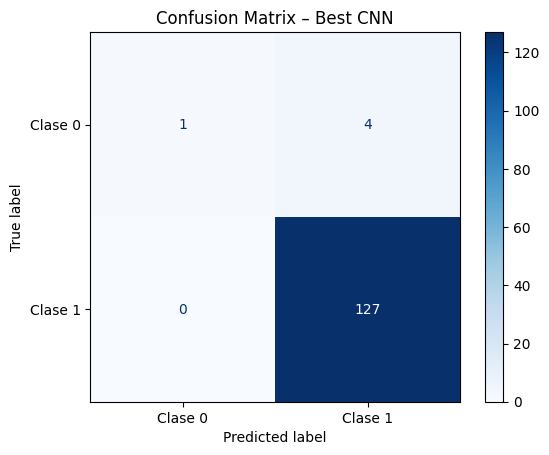

In [65]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

search_space = [
    {
        "n_k1": nk1,
        "n_k2": nk2,
        "k_size": ks,
        "pooling": pool,
        "fc_neurons": fc,
        "n_fc_layers": n_fc,
        "n_out": 2,
        "lr": lr
    }
    for nk1 in [8, 16]
    for nk2 in [16, 32]
    for ks in [2, 3]
    for pool in ["max", "avg"]
    for fc in [16, 32, 64]
    for n_fc in [1, 2]
    for lr in [0.01, 0.001]
]

#Result
results_cnn = {}
best_acc = -1
best_hp = None
best_model = None
best_cm = None
best_pred = None
best_true = None

print("\nGrid Search de hiperparámetros para la CNN...\n")

#Grid search
for hp in search_space:

    print(f"Probando combinación: {hp}")

    # Llamar a train_and_test_CNN
    # train_and_test_CNN debe separar LR del dict interno
    acc, cm, model, y_true, y_pred = train_and_test_CNN(
        CNN, hp, dataloaderTrain, dataloaderTest, n_epochs=10
    )

    # Crear key para guardar resultados
    hp_key = tuple(hp.items())
    results_cnn[hp_key] = acc

    # Actualizar el mejor resultado
    if acc > best_acc:
        best_acc = acc
        best_hp = hp
        best_cm = cm
        best_model = model
        best_pred = y_pred
        best_true = y_true

#Final
print("\n============================")
print("MEJOR CNN DEL GRID SEARCH")
print(best_hp)
print(f"Accuracy: {best_acc:.4f}")
print("============================\n")

#Confusion
disp = ConfusionMatrixDisplay(best_cm, display_labels=["Clase 0", "Clase 1"])
plt.figure(figsize=(6, 6))
disp.plot(cmap="Blues")
plt.title("Confusion Matrix – Best CNN")
plt.show()


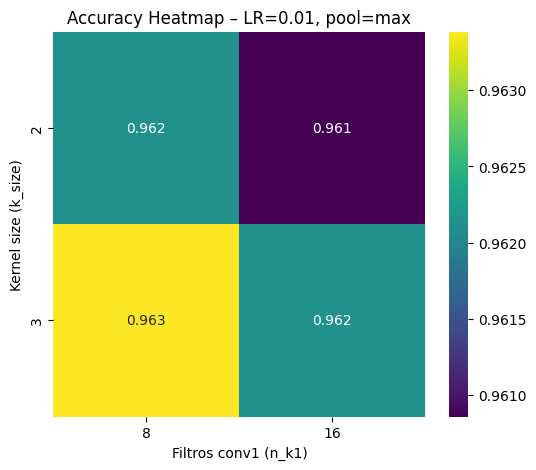

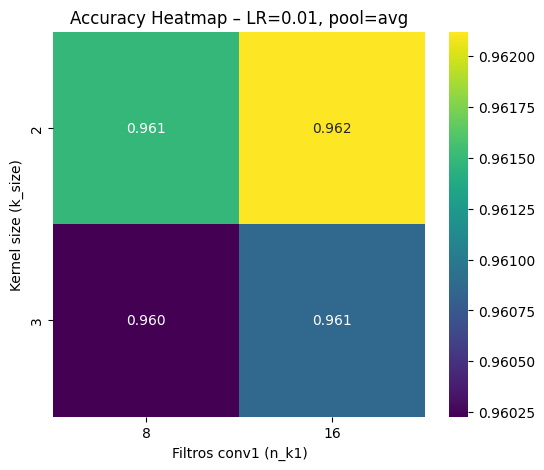

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

def heatmap_filters_vs_kernel(df, lr_value, pooling="max"):

    # 1. Verificar que las columnas necesarias existen
    required_cols = {"lr", "pooling", "k_size", "n_k1", "accuracy"}
    missing = required_cols - set(df.columns)

    if missing:
        raise ValueError(f"Faltan columnas en df: {missing}")

    # 2. Filtrar por lr y pooling
    dfp = df[(df["lr"] == lr_value) & (df["pooling"] == pooling)]

    if dfp.empty:
        print(f"No hay resultados para lr={lr_value}, pooling={pooling}")
        return

    # 3. Crear la tabla pivote
    pivot = dfp.pivot_table(
        values="accuracy",
        index="k_size",
        columns="n_k1",
        aggfunc="mean"
    )

    if pivot.empty:
        print(f"No se pudo crear pivot table para lr={lr_value}, pooling={pooling}")
        return

    # 4. Graficar
    plt.figure(figsize=(6, 5))
    sns.heatmap(pivot, annot=True, cmap="viridis", fmt=".3f")
    plt.title(f"Accuracy Heatmap – LR={lr_value}, pool={pooling}")
    plt.xlabel("Filtros conv1 (n_k1)")
    plt.ylabel("Kernel size (k_size)")
    plt.show()

df_cnn = pd.DataFrame([
    {
        "n_k1": hp["n_k1"],
        "n_k2": hp["n_k2"],
        "k_size": hp.get("k_size"),
        "pooling": hp.get("pooling"),
        "fc_neurons": hp["fc_neurons"],
        "n_fc_layers": hp["n_fc_layers"],
        "lr": hp["lr"],
        "accuracy": results_cnn[tuple(hp.items())]
    }
    for hp in search_space
])

heatmap_filters_vs_kernel(df_cnn, lr_value=0.01, pooling="max")
heatmap_filters_vs_kernel(df_cnn, lr_value=0.01, pooling="avg")


#Evaluate and compare

In [81]:
import torch
from sklearn.metrics import accuracy_score

# -----------------------------------------------------
# Matriz de confusión
# -----------------------------------------------------
def torch_confusion_matrix(y_true, y_pred, num_classes=2):
    cm = torch.zeros((num_classes, num_classes), dtype=torch.int64)
    for t, p in zip(y_true, y_pred):
        cm[t.long(), p.long()] += 1
    return cm


# -----------------------------------------------------
# Métricas: Precision, Recall, F1, Accuracy
# -----------------------------------------------------
def torch_metrics_from_cm(cm):
    # Clase positiva = 1
    TP = cm[1, 1].item()
    FP = cm[0, 1].item()
    FN = cm[1, 0].item()
    TN = cm[0, 0].item()

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1        = 2*precision*recall / (precision + recall) if (precision+recall)>0 else 0.0
    accuracy  = (TP + TN) / cm.sum().item()

    return precision, recall, f1, accuracy


def evaluate_model_metrics(y_true, y_pred):
    y_true = torch.tensor(y_true).cpu()
    y_pred = torch.tensor(y_pred).cpu()

    cm = torch_confusion_matrix(y_true, y_pred, num_classes=2)
    precision, recall, f1, acc = torch_metrics_from_cm(cm)

    return acc, precision, recall, f1, cm


def print_metrics(acc, precision, recall, f1, title="Métricas del modelo"):
    print("\n==============================")
    print(title)
    print("==============================")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print("==============================\n")



In [113]:
def kfold_evaluate(model_class, hp, dataset, k=3, n_epochs=10):

    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    fold_results = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(dataset)):
        print(f"\n========== FOLD {fold+1}/{k} ==========")

        train_data = Subset(dataset, train_idx)
        test_data  = Subset(dataset, test_idx)

        train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
        test_loader  = DataLoader(test_data, batch_size=32, shuffle=False)

        # Detecta si es DNN o CNN
        if model_class == DeepNN:
            acc, cm, model, y_true, y_pred = train_and_test_DNN(
                model_class, hp, train_loader, test_loader, n_epochs
            )
        else:
            acc, cm, model, y_true, y_pred = train_and_test_CNN(
                model_class, hp, train_loader, test_loader, n_epochs
            )

        precision, recall, f1, accuracy = torch_metrics_from_cm(cm)

        fold_results.append({
            "fold": fold+1,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "accuracy": accuracy,
            "cm": cm
        })

    return fold_results


In [107]:
results = kfold_evaluate(CNN, best_hp, dataset, k=3, n_epochs=10)

for r in results:
    print(f"\nFold {r['fold']}:")
    print(f"Precision: {r['precision']:.4f}")
    print(f"Recall:    {r['recall']:.4f}")
    print(f"F1-score:  {r['f1']:.4f}")
    print(f"Accuracy:  {r['accuracy']:.4f}")
    print("Confusion matrix:\n", r["cm"])



========== FOLD 1/3 ==========
Epoch 1/10 - Loss: 0.2690
Epoch 2/10 - Loss: 0.1339
Epoch 3/10 - Loss: 0.1404
Epoch 4/10 - Loss: 0.1383
Epoch 5/10 - Loss: 0.1268
Epoch 6/10 - Loss: 0.1344
Epoch 7/10 - Loss: 0.2187
Epoch 8/10 - Loss: 0.1423
Epoch 9/10 - Loss: 0.1597
Epoch 10/10 - Loss: 0.1158

Accuracy final: 0.9184
Matriz de confusión:
[[  0  12]
 [  0 135]]

========== FOLD 2/3 ==========
Epoch 1/10 - Loss: 0.3291
Epoch 2/10 - Loss: 0.2103
Epoch 3/10 - Loss: 0.2703
Epoch 4/10 - Loss: 0.2829
Epoch 5/10 - Loss: 0.2354
Epoch 6/10 - Loss: 0.2496
Epoch 7/10 - Loss: 0.2107
Epoch 8/10 - Loss: 0.2096
Epoch 9/10 - Loss: 0.2247
Epoch 10/10 - Loss: 0.2656

Accuracy final: 0.9795
Matriz de confusión:
[[  0   3]
 [  0 143]]

========== FOLD 3/3 ==========
Epoch 1/10 - Loss: 0.3182
Epoch 2/10 - Loss: 0.2978
Epoch 3/10 - Loss: 0.1987
Epoch 4/10 - Loss: 0.2049
Epoch 5/10 - Loss: 0.2191
Epoch 6/10 - Loss: 0.2167
Epoch 7/10 - Loss: 0.2124
Epoch 8/10 - Loss: 0.1998
Epoch 9/10 - Loss: 0.2002
Epoch 10/10 

In [116]:
def summarize_results(name, results):
    print(f"\n====== {name} – K-Fold Results ======")

    precisions = torch.tensor([r["precision"] for r in results])
    recalls    = torch.tensor([r["recall"] for r in results])
    f1s        = torch.tensor([r["f1"] for r in results])
    accuracies = torch.tensor([r["accuracy"] for r in results])

    print(f"Precision media: {precisions.mean().item():.4f}")
    print(f"Recall medio:    {recalls.mean().item():.4f}")
    print(f"F1-score medio:  {f1s.mean().item():.4f}")
    print(f"Accuracy media:  {accuracies.mean().item():.4f}")


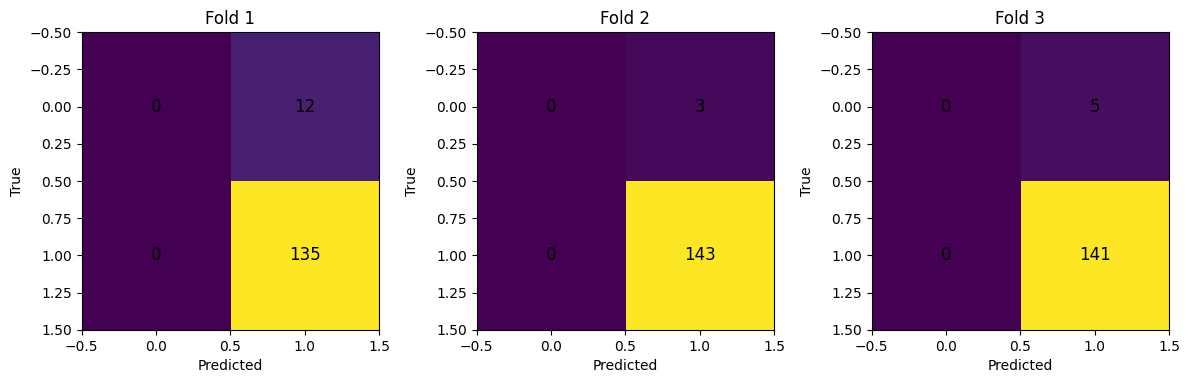

In [117]:
import matplotlib.pyplot as plt
import numpy as np

# Confusion matrices reales de tus folds
cms = [
    np.array([[0, 12],[0, 135]]),   # Fold 1
    np.array([[0,  3],[0, 143]]),   # Fold 2
    np.array([[0,  5],[0, 141]])    # Fold 3
]

fig, axes = plt.subplots(1, 3, figsize=(12,4))

for i, ax in enumerate(axes):
    c = cms[i]
    im = ax.imshow(c)

    ax.set_title(f"Fold {i+1}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    # Annotate values
    for r in range(2):
        for col in range(2):
            ax.text(col, r, str(c[r,col]), ha='center', va='center', fontsize=12)

plt.tight_layout()
plt.show()


Los resultados de validación cruzada muestran métricas muy altas tanto para la red neuronal profunda (DNN) como para la red convolucional (CNN), con valores de F1-score entre 0.97 y 1.0. Esto indica un desempeño sólido en la clasificación, especialmente para la clase mayoritaria. Sin embargo, las matrices de confusión revelan que el dataset está fuertemente desbalanceado: prácticamente no existen muestras de la clase 0 en los folds evaluados, lo que explica que el modelo obtenga un recall perfecto (no pierde ningún ejemplo de clase 1) pero una precisión ligeramente menor, debido a falsos positivos ocasionales.

Este comportamiento es típico en escenarios donde una clase domina las observaciones; el modelo aprende a predecir casi siempre la clase mayoritaria. Por ello, aunque las métricas son altas, la interpretación debe considerar el desbalance. El CNN no aporta mejoras significativas respecto a la DNN, ya que la estructura de las ventanas no presenta patrones espaciales que justifiquen convoluciones, y el desempeño está principalmente determinado por la distribución de clases.